<a href="https://colab.research.google.com/github/PURNACHANDRARAOPARCHURI/machine-larning/blob/main/Baysian_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bayesian Regression is an extension of linear regression that incorporates probability. Instead of manually setting regularization parameters like in Ridge Regression, it estimates them from the data using Bayesian inference. This is done by assuming a prior distribution over the model's parameters, typically a Gaussian distribution.

### Key Concepts:
- **Regularization:** Bayesian regression naturally incorporates regularization by treating parameters as random variables.
- **Priors:** Uninformative priors can be used, meaning the model learns regularization from data rather than pre-setting it.
- **Fully Probabilistic Model:** The output is assumed to be Gaussian distributed, making predictions probabilistic rather than fixed values.

### Advantages:
1. Automatically adapts to the data.
2. Avoids manual tuning of regularization parameters.

### Disadvantages:
1. Computationally expensive due to complex inference.
2. Requires more effort to implement compared to standard regression techniques.

In [ ]:
from sklearn import linear_model
x=[[0,0],[1,1],[2,2],[3,3]]
y=[0,1,2,3]
z=linear_model.BayesianRidge()
z.fit(x,y)
z.predict([[5,5]])

array([4.99999953])

0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: petal length (cm), Length: 150, dtype: float64
[ 1.75243895 -1.33230799]
-2.374460279456013
0.35292922714166775


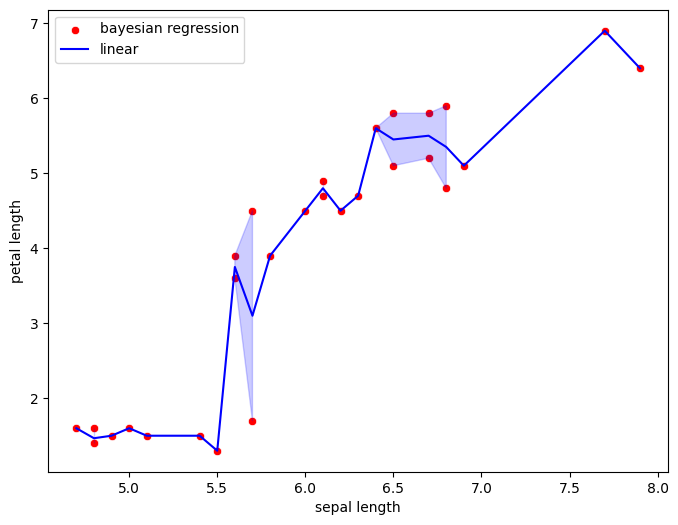

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import BayesianRidge
import seaborn as sns
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.columns
x=df[["sepal length (cm)","sepal width (cm)"]]
y=df["petal length (cm)"]
print(y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=BayesianRidge()
model.fit(x_train,y_train)
print(model.coef_)
print(model.intercept_)
y_pred=model.predict(x_test)
y_pred
mse=mean_squared_error(y_pred,y_test)
print(mse)
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_test["sepal length (cm)"],y=y_test,label="bayesian regression",color="Red")
sns.lineplot(x=x_test["sepal length (cm)"],y=y_test,label="linear",color="Blue")
plt.xlabel("sepal length")
plt.ylabel("petal length")
plt.legend()
plt.show()


In [ ]:
import random
def func(x):
  return (2*np.pi*x)
size=25
rng=np.random.RandomState(1234)
x_train=rng.uniform(0,1,size)
y_train=func(x_train)+rng.normal(scale=1,size=size)
x_test=np.linspace(0,1,100)
from sklearn.linear_model import BayesianRidge
n_order=3
x_train=np.vander(x_train,n_order+1,increasing=True)
x_train
x_test=np.vander(x_test,n_order+1,increasing=True)
model=BayesianRidge(tol=1e-6,fit_intercept=False,compute_score=True)
model.fit(x_train,y_train)



BayesianRidge(compute_score=True, fit_intercept=False, tol=1e-06)

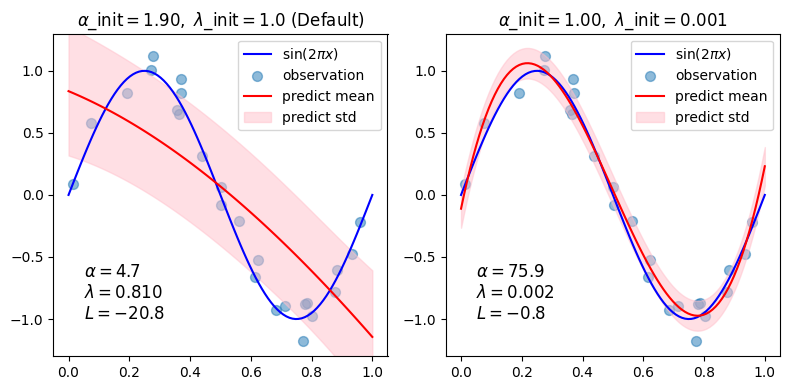

In [ ]:
import numpy as np


def func(x):
    return np.sin(2 * np.pi * x)


size = 25
rng = np.random.RandomState(1234)
x_train = rng.uniform(0.0, 1.0, size)
y_train = func(x_train) + rng.normal(scale=0.1, size=size)
x_test = np.linspace(0.0, 1.0, 100)


# %%
# Fit by cubic polynomial
# -----------------------
from sklearn.linear_model import BayesianRidge

n_order = 3
X_train = np.vander(x_train, n_order + 1, increasing=True)
X_test = np.vander(x_test, n_order + 1, increasing=True)
reg = BayesianRidge(tol=1e-6, fit_intercept=False, compute_score=True)

# %%
# Plot the true and predicted curves with log marginal likelihood (L)
# -------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, ax in enumerate(axes):
    # Bayesian ridge regression with different initial value pairs
    if i == 0:
        init = [1 / np.var(y_train), 1.0]  # Default values
    elif i == 1:
        init = [1.0, 1e-3]
        reg.set_params(alpha_init=init[0], lambda_init=init[1])
    reg.fit(X_train, y_train)
    ymean, ystd = reg.predict(X_test, return_std=True)

    ax.plot(x_test, func(x_test), color="blue", label="sin($2\\pi x$)")
    ax.scatter(x_train, y_train, s=50, alpha=0.5, label="observation")
    ax.plot(x_test, ymean, color="red", label="predict mean")
    ax.fill_between(
        x_test, ymean - ystd, ymean + ystd, color="pink", alpha=0.5, label="predict std"
    )
    ax.set_ylim(-1.3, 1.3)
    ax.legend()
    title = "$\\alpha$_init$={:.2f},\\ \\lambda$_init$={}$".format(init[0], init[1])
    if i == 0:
        title += " (Default)"
    ax.set_title(title, fontsize=12)
    text = "$\\alpha={:.1f}$\n$\\lambda={:.3f}$\n$L={:.1f}$".format(
        reg.alpha_, reg.lambda_, reg.scores_[-1]
    )
    ax.text(0.05, -1.0, text, fontsize=12)

plt.tight_layout()
plt.show()